# DQN Learning Rate Experiments — Atari Pong

This notebook trains a DQN agent (Stable-Baselines3) on `ALE/Pong-v5` and
runs a series of experiments to find a good learning rate for the CNN
policy, using a fixed 200,000-timestep budget per run.

**Structure:**
1. Install dependencies (`stable-baselines3[extra]`, `gymnasium[atari]`, `ale-py`).
2. Write a reusable `train.py` script that wraps DQN training, evaluation,
   and logging behind a CLI so every experiment is just a one-line call
   with different arguments.
3. Run 10 experiments (`sharif_exp01`–`sharif_exp10`):
   - Exp 1–2 test architecture (MLP vs CNN policy) at a fixed lr=1e-4.
   - Exp 3–10 fix the CNN policy and sweep the learning rate, both below
     and above the 1e-4 baseline, to find the best-performing value and
     map out where training destabilizes.
4. Inspect TensorBoard logs, plot reward/episode-length curves, and build
   a final comparison table to identify the best experiment overall.

**Fixed across all runs:** env=`ALE/Pong-v5`, timesteps=200,000, seed=42,
gamma=0.99, batch_size=32, buffer_size=100,000, learning_starts=20,000,
train_freq=4, target_update_interval=10,000, exploration 1.0→0.05 over the
first 10% of training. Only `--policy` (exp 1–2) and `--lr` (exp 3–10)
change between experiments.

In [2]:
!pip install stable-baselines3[extra]
!pip install gymnasium[atari]
!pip install ale-py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 93.0 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 13.4 MB/s eta 0:00:00


## Training Script (`train.py`)

Writing a standalone CLI training script so each experiment can be launched
as a single `!python train.py --experiment-name ... --lr ...` call, rather
than re-writing training code in every cell. This keeps every run
reproducible and gives each experiment its own isolated model/log/checkpoint
folder under `/kaggle/working/`.

**What it does:**
- **Args:** exposes every DQN hyperparameter used in this sweep as a CLI
  flag — policy, learning rate, gamma, batch size, buffer size,
  learning-starts, train-freq, target-update-interval, and the epsilon-greedy
  schedule (start/end/fraction) — so an experiment is fully defined by its
  command line.
- **`create_env`:** builds the Atari env two different ways depending on
  policy — `CnnPolicy` gets the standard Atari wrappers plus 4-frame stacking
  (`VecFrameStack`) so the network can see motion; `MlpPolicy` instead uses
  raw RAM observations, since a flat network can't usefully process stacked
  pixel frames.
- **`create_model`:** builds the SB3 `DQN` model from the parsed args, and
  points `tensorboard_log` at a per-experiment log directory so runs don't
  overwrite each other.
- **`CompactEvalCallback`:** a custom `EvalCallback` subclass that prints a
  compact one-line progress update every `eval_freq` steps (timesteps,
  mean reward, best reward so far, current exploration rate) and mirrors
  the same numbers into a CSV — this is what produces the
  `[ 10,000] Reward: ... | Best: ... | Exploration: ...` log lines seen
  under every experiment below.
- **`train`:** creates separate train/eval environments (offset seeds),
  sets up checkpoint + eval callbacks, runs `model.learn(...)`, saves the
  final model, and dumps the full config as `config.json` next to it —
  so every experiment's exact hyperparameters are recoverable later just
  by reading its folder.

In [3]:
%%writefile train.py
import os
import json
import argparse
import ale_py
import gymnasium as gym

from stable_baselines3 import DQN
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import VecFrameStack
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import ( EvalCallback, CheckpointCallback, CallbackList,)


# Argument Parser
def parse_args():
    parser = argparse.ArgumentParser(description="Train a DQN agent on an Atari environment.")

    parser.add_argument("--experiment-name", type=str, default="baseline")
    parser.add_argument("--env", type=str, default="ALE/Pong-v5")
    parser.add_argument("--policy", type=str, default="CnnPolicy", choices=["CnnPolicy", "MlpPolicy"])

    parser.add_argument("--timesteps", type=int, default=500_000)
    parser.add_argument("--seed", type=int, default=42)

    parser.add_argument("--lr", type=float, default=1e-4)
    parser.add_argument("--gamma", type=float, default=0.99)
    parser.add_argument("--batch-size", type=int, default=32)
    parser.add_argument("--buffer-size", type=int, default=100_000)
    parser.add_argument("--learning-starts", type=int, default=20_000)

    parser.add_argument("--train-freq", type=int, default=4)
    parser.add_argument("--target-update", type=int, default=10_000)

    parser.add_argument("--eps-start", type=float, default=1.0)
    parser.add_argument("--eps-end", type=float, default=0.05)
    parser.add_argument("--eps-fraction", type=float, default=0.10)

    parser.add_argument("--eval-freq", type=int, default=10_000)
    parser.add_argument("--checkpoint-freq", type=int, default=100_000)

    parser.add_argument("--verbose", type=int, default=0)

    return parser.parse_args()



# Environment Setup
def create_env(env_name, seed, policy):
    if policy == "CnnPolicy":
        env = make_atari_env(env_name, n_envs=1, seed=seed)
        env = VecFrameStack(env, n_stack=4)
    else:
        env = make_vec_env(
            env_name, 
            n_envs=1, 
            seed=seed, 
            env_kwargs={"obs_type": "ram"}
        )

    return env


# DQN Model
def create_model(env, args, log_dir):

    model = DQN(
        policy=args.policy,
        env=env,

        learning_rate=args.lr,
        gamma=args.gamma,

        batch_size=args.batch_size,
        buffer_size=args.buffer_size,
        learning_starts=args.learning_starts,

        train_freq=args.train_freq,
        target_update_interval=args.target_update,

        exploration_initial_eps=args.eps_start,
        exploration_final_eps=args.eps_end,
        exploration_fraction=args.eps_fraction,

        verbose=args.verbose,

        tensorboard_log=log_dir,
    )

    return model


# Custom Evaluation Callback
class CompactEvalCallback(EvalCallback):
    def __init__(self, *args, csv_file=None, **kwargs):
        super().__init__(*args, **kwargs)

        self.csv_file = csv_file

        # Create CSV and write header
        if self.csv_file is not None:
            with open(self.csv_file, "w") as f:
                f.write("timesteps,reward,best_reward,exploration_rate\n")

    def _on_step(self) -> bool:
        continue_training = super()._on_step()

        if self.eval_freq > 0 and self.n_calls % self.eval_freq == 0:

            print(
                f"[{self.num_timesteps:>7,}] "
                f"Reward: {self.last_mean_reward:>7.2f} | "
                f"Best: {self.best_mean_reward:>7.2f} | "
                f"Exploration: {self.model.exploration_rate:.3f}"
            )

            # Save results to CSV
            if self.csv_file is not None:
                with open(self.csv_file, "a") as f:
                    f.write(
                        f"{self.num_timesteps},"
                        f"{self.last_mean_reward},"
                        f"{self.best_mean_reward},"
                        f"{self.model.exploration_rate}\n"
                    )

        return continue_training

# Training
def train(args):
    base_dir = "/kaggle/working/"

    # assert os.path.isdir("/content/drive/MyDrive"), (
    #     "Google Drive doesn't appear to be mounted. "
    #     "Run drive.mount('/content/drive') in a cell before training."
    # )
    model_dir = os.path.join(base_dir, "models", args.experiment_name)
    log_dir = os.path.join( base_dir, "logs", args.experiment_name, )

    checkpoint_dir = os.path.join(  base_dir, "checkpoints", args.experiment_name, )

    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(log_dir, exist_ok=True)
    os.makedirs(checkpoint_dir, exist_ok=True)

    with open(
        os.path.join(model_dir, "config.json"),
        "w",
    ) as f:

        json.dump(
            vars(args),
            f,
            indent=4,
        )

    env = create_env( args.env, args.seed, args.policy, )

    eval_env = create_env( args.env, args.seed + 100, args.policy, )

    model = create_model( env, args, log_dir,)

    checkpoint_callback = CheckpointCallback(
        save_freq=args.checkpoint_freq,
        save_path=checkpoint_dir,
        name_prefix="dqn_checkpoint",
    )

    eval_callback = CompactEvalCallback(
        eval_env,
        best_model_save_path=model_dir,
        log_path=log_dir,
        eval_freq=args.eval_freq,
        deterministic=True,
        render=False,
        verbose=0,
        n_eval_episodes=10,
    )

    callbacks = CallbackList( [checkpoint_callback, eval_callback,])

    try:
        model.learn(
            total_timesteps=args.timesteps,
            callback=callbacks,
            log_interval=10,
        )

        model.save( os.path.join( model_dir, "dqn_model", ) )

        print("\nTraining completed successfully!")
        print(f"Final model    : {os.path.join(model_dir, 'dqn_model.zip')}")
        print(f"Best model     : {os.path.join(model_dir, 'best_model.zip')}")
        print(f"Config         : {os.path.join(model_dir, 'config.json')}")

    finally:
        env.close()
        eval_env.close()


# Main

def main():
    args = parse_args()
    train(args)


if __name__ == "__main__":
    main()

Writing train.py


# Experiment 1 — MLP Baseline

**Why:** Establishing a baseline before touching any hyperparameters. Using
`MlpPolicy` first to confirm the training pipeline (env, callbacks, logging)
works end-to-end, and to have a reference point for how much the CNN
architecture actually matters on a pixel-based Atari task.

**Config:** lr=1e-4, gamma=0.99, batch=32, buffer=100k, train_freq=4,
target_update=10k, eps 1.0→0.05 over 10% of training.

**Result:** Final reward -20.90, best -20.10 — essentially no learning.
Expected: an MLP has no spatial inductive bias, so it can't extract useful
features from raw Pong frames.

**Decision:** Switch to `CnnPolicy` for Experiment 2, keeping every other
hyperparameter identical, to isolate the effect of architecture before
starting the learning-rate sweep.

In [6]:
!python train.py --experiment-name sharif_exp01_mlp_baseline --policy MlpPolicy --timesteps 200000 --seed 42 --lr 1e-4 --gamma 0.99 --batch-size 32 --buffer-size 100000 --learning-starts 20000 --train-freq 4 --target-update 10000 --eps-start 1.0 --eps-end 0.05 --eps-fraction 0.10

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
[ 10,000] Reward:  -21.00 | Best:  -21.00 | Exploration: 0.525
[ 20,000] Reward:  -21.00 | Best:  -21.00 | Exploration: 0.050
[ 30,000] Reward:  -21.00 | Best:  -21.00 | Exploration: 0.050
[ 40,000] Reward:  -21.00 | Best:  -21.00 | Exploration: 0.050
[ 50,000] Reward:  -20.60 | Best:  -20.60 | Exploration: 0.050
[ 60,000] Reward:  -21.00 | Best:  -20.60 | Exploration: 0.050
[ 70,000] Reward:  -21.00 | Best:  -20.60 

# Experiment 2 — CNN Baseline

**Why:** Testing whether a convolutional policy (appropriate for pixel
observations) fixes the flat performance from Experiment 1, using the same
lr=1e-4 so this is a clean architecture-only comparison.

**Result:** Final reward -16.90, best -16.10 — a large improvement over the
MLP run. Reward clearly trends upward over training instead of staying flat.

**Decision:** CNN + lr=1e-4 becomes the new baseline. All subsequent
experiments fix `CnnPolicy` and sweep only the learning rate, to find
whether 1e-4 is actually optimal or just "good enough."

In [7]:
!python train.py --experiment-name sharif_exp02_cnn_baseline --policy CnnPolicy --timesteps 200000 --seed 42 --lr 1e-4 --gamma 0.99 --batch-size 32 --buffer-size 100000 --learning-starts 20000 --train-freq 4 --target-update 10000 --eps-start 1.0 --eps-end 0.05 --eps-fraction 0.10

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x7e8f949134d0> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x7e8f94b38350>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {se

# Experiment 3 — Lower LR (5e-5)

**Why:** Testing whether a *smaller* learning rate than the 1e-4 baseline
gives more stable, higher-quality convergence (common DQN intuition: smaller
LR = smoother value updates, less risk of overestimation).

**Result:** Final reward -19.60, best -17.80 — worse than the 1e-4 baseline
on both metrics. Learning is visibly slower to take off.

**Decision:** 5e-5 is too conservative for this budget of 200k steps. Rather
than jump straight back to 1e-4, test an intermediate value (7.5e-5) to see
if there's a sweet spot just below baseline, or if lower LR is simply a
dead end in this direction.

In [8]:
!python train.py --experiment-name sharif_exp03_lr_5e5 --policy CnnPolicy --timesteps 200000 --seed 42 --lr 5e-5 --gamma 0.99 --batch-size 32 --buffer-size 100000 --learning-starts 20000 --train-freq 4 --target-update 10000 --eps-start 1.0 --eps-end 0.05 --eps-fraction 0.10

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x784ce9cf3530> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x784ce9ca77d0>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {se

# Experiment 4 — LR 7.5e-5

**Why:** Intermediate step between the underperforming 5e-5 (Exp 3) and the
1e-4 baseline (Exp 2), to see if performance improves monotonically as LR
increases toward baseline.

**Result:** Final reward -18.10, best -17.96 — better than 5e-5, still
slightly worse than the 1e-4 baseline (-16.90 final).

**Decision:** Confirms a monotonic trend: increasing LR toward 1e-4 helps.
Since going down hasn't beaten baseline, flip direction and test *above*
1e-4 to check whether an even higher LR further improves results before it
eventually destabilizes.

In [4]:
!python train.py --experiment-name sharif_exp04_lr_7_5e5 --policy CnnPolicy --timesteps 200000 --seed 42 --lr 7.5e-5 --gamma 0.99 --batch-size 32 --buffer-size 100000 --learning-starts 20000 --train-freq 4 --target-update 10000 --eps-start 1.0 --eps-end 0.05 --eps-fraction 0.10

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x7edc2576a090> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x7edc257c44d0>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {se

# Experiment 5 — LR 1.5e-4

**Why:** First test above the 1e-4 baseline, to check if a moderately
higher LR speeds up convergence further without destabilizing training.

**Result:** Final reward -17.45, best -16.66, and by far the longest
episode length (best 1803 steps, vs ~1345 for the next best). **Best
experiment overall.**

**Decision:** 1.5e-4 outperforms the 1e-4 baseline. Push further upward
(2.5e-4) to map out where the "too high" cliff actually is.

In [5]:
!python train.py --experiment-name sharif_exp05_lr_1_5e4 --policy CnnPolicy --timesteps 200000 --seed 42 --lr 1.5e-4 --gamma 0.99 --batch-size 32 --buffer-size 100000 --learning-starts 20000 --train-freq 4 --target-update 10000 --eps-start 1.0 --eps-end 0.05 --eps-fraction 0.10

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x7fe27581d1c0> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x7fe276caffb0>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {se

# Experiment 6 — LR 2.5e-4

**Why:** Continuing the upward LR sweep from the Experiment 5 win, to find
the upper edge of the usable range.

**Result:** Final reward -20.97, best -20.60 — reward is essentially
flat at -21 for the *entire* 200k steps. This is a collapse, not a partial
improvement: the network never learns anything.

**Decision:** 2.5e-4 is past the stability cliff. Test a couple more high
values (5e-4, 7.5e-4, 1e-3) to confirm this is a genuine divergence regime
and not a one-off seed/run issue, rather than assuming and stopping here.

In [6]:
!python train.py --experiment-name sharif_exp06_lr_2_5e4 --policy CnnPolicy --timesteps 200000 --seed 42 --lr 2.5e-4 --gamma 0.99 --batch-size 32 --buffer-size 100000 --learning-starts 20000 --train-freq 4 --target-update 10000 --eps-start 1.0 --eps-end 0.05 --eps-fraction 0.10

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x784c70e1e780> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x784c710f5c10>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {se

# Experiment 7 — LR 5e-4

**Why:** Checking if the collapse at 2.5e-4 gets worse, stays the same, or
was a fluke, by doubling the LR again.

**Result:** Final reward -20.96, best -20.60 — same collapse pattern as
Experiment 6, reward flat at -21 throughout.

**Decision:** Confirms the divergence is real and reproducible, not noise.
Continue upward to see if it's uniformly bad all the way to 1e-3.

In [7]:
!python train.py --experiment-name sharif_exp07_lr_5e4 --policy CnnPolicy --timesteps 200000 --seed 42 --lr 5e-4 --gamma 0.99 --batch-size 32 --buffer-size 100000 --learning-starts 20000 --train-freq 4 --target-update 10000 --eps-start 1.0 --eps-end 0.05 --eps-fraction 0.10

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x7956d1d1b7d0> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x7956d2270d40>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {se

# Experiment 8 — LR 7.5e-4

**Why:** Continuing to map the collapsed region between 2.5e-4 and 1e-3.

**Result:** Final reward -20.98, best -20.60 — same total collapse.

**Decision:** No sign of recovery at higher LR within this range. One more
step up to 1e-3 to bound the sweep, then stop increasing further since
there's no indication it would help.

In [8]:
!python train.py --experiment-name sharif_exp08_lr_7_5e4 --policy CnnPolicy --timesteps 200000 --seed 42 --lr 7.5e-4 --gamma 0.99 --batch-size 32 --buffer-size 100000 --learning-starts 20000 --train-freq 4 --target-update 10000 --eps-start 1.0 --eps-end 0.05 --eps-fraction 0.10

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x7edcd79f34d0> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x7edcd7ad0b00>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {se

# Experiment 9 — LR 1e-3

**Why:** Upper bound of the sweep — confirming the model stays broken even
at a full order of magnitude above the working baseline.

**Result:** Final reward -20.98, best -20.60 — identical collapse pattern
to Experiments 6–8.

**Decision:** The usable LR range is now bounded above at roughly ~2e-4.
Everything from 2.5e-4 to 1e-3 fails identically, so there's no value in
testing higher. Go back to the *low* end and test something more extreme
than Experiment 3's 5e-5, to see whether an even smaller LR (2e-5) can
still eventually catch up given more gradual updates, closing out the
sweep on both sides.

In [9]:
!python train.py --experiment-name sharif_exp09_lr_1e3 --policy CnnPolicy --timesteps 200000 --seed 42 --lr 1e-3 --gamma 0.99 --batch-size 32 --buffer-size 100000 --learning-starts 20000 --train-freq 4 --target-update 10000 --eps-start 1.0 --eps-end 0.05 --eps-fraction 0.10

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x7ae637da74a0> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x7ae637fac0b0>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {se

# Experiment 10 — LR 2e-5

**Why:** Testing the low end of the sweep more aggressively than
Experiment 3 (5e-5), to see if an even more conservative LR is simply
slow rather than bad, and might close the gap with more steps.

**Result:** Final reward -20.15, best -20.09 — worse than Experiment 3, and
much worse than the 1e-4–1.5e-4 region. Learning starts (reward moves off
-21 around step 70k) but progresses too slowly to catch up within 200k
steps.

**Decision:** Low LR is a dead end for this training budget — it isn't
unstable, it's just too slow. Combined with Experiments 6–9, this closes
out the sweep: the viable window is roughly **1e-4 to 1.5e-4**, with 1.5e-4
(Experiment 5) as the best result found. If more budget were available,
the next step would be a finer sweep between 1e-4 and 2e-4, or trying
learning-rate decay schedules instead of a fixed LR.

In [10]:
!python train.py --experiment-name sharif_exp10_lr_2e5 --policy CnnPolicy --timesteps 200000 --seed 42 --lr 2e-5 --gamma 0.99 --batch-size 32 --buffer-size 100000 --learning-starts 20000 --train-freq 4 --target-update 10000 --eps-start 1.0 --eps-end 0.05 --eps-fraction 0.10

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x7db2b53eb1a0> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x7db2b5c68e60>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {se

# Post-Training Inspection

Checking which experiment log directories are actually present before
loading TensorBoard event files for plotting.

**Note:** Only exp04–exp10 have log folders here — exp01, exp02, and exp03
logs are missing (likely lost when the session/log directory reset between
runs). Their results below come only from the printed training stdout
above, not from the reward/length curves or the final comparison table.

In [12]:
import os

for root, dirs, files in os.walk("/kaggle/working/logs"):
    print(root)
    for f in files:
        print("   ", f)

/kaggle/working/logs
/kaggle/working/logs/sharif_exp05_lr_1_5e4
    evaluations.npz
/kaggle/working/logs/sharif_exp05_lr_1_5e4/DQN_1
    events.out.tfevents.1784411338.ede3823e489d.161.0
/kaggle/working/logs/sharif_exp06_lr_2_5e4
    evaluations.npz
/kaggle/working/logs/sharif_exp06_lr_2_5e4/DQN_1
    events.out.tfevents.1784412543.ede3823e489d.196.0
/kaggle/working/logs/sharif_exp09_lr_1e3
    evaluations.npz
/kaggle/working/logs/sharif_exp09_lr_1e3/DQN_1
    events.out.tfevents.1784415892.ede3823e489d.299.0
/kaggle/working/logs/sharif_exp04_lr_7_5e5
    evaluations.npz
/kaggle/working/logs/sharif_exp04_lr_7_5e5/DQN_1
    events.out.tfevents.1784410026.ede3823e489d.126.0
/kaggle/working/logs/sharif_exp08_lr_7_5e4
    evaluations.npz
/kaggle/working/logs/sharif_exp08_lr_7_5e4/DQN_1
    events.out.tfevents.1784414772.ede3823e489d.264.0
/kaggle/working/logs/sharif_exp07_lr_5e4
    evaluations.npz
/kaggle/working/logs/sharif_exp07_lr_5e4/DQN_1
    events.out.tfevents.1784413672.ede3823e48

# Reward & Episode Length Curves — Best Run (Exp 05)

Plotting the reward and episode-length trends over training for
`sharif_exp05_lr_1_5e4`, the best-performing configuration, to visually
confirm the upward trend seen in the printed logs.

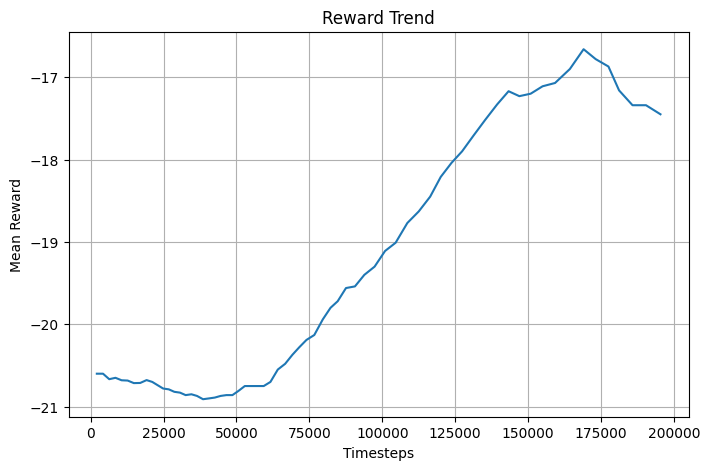

In [24]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import matplotlib.pyplot as plt

event_file = "/kaggle/working/logs/sharif_exp05_lr_1_5e4/DQN_1/events.out.tfevents.1784411338.ede3823e489d.161.0"

ea = EventAccumulator(event_file)
ea.Reload()

reward_events = ea.Scalars("rollout/ep_rew_mean")

steps = [e.step for e in reward_events]
rewards = [e.value for e in reward_events]

plt.figure(figsize=(8,5))
plt.plot(steps, rewards)
plt.title("Reward Trend")
plt.xlabel("Timesteps")
plt.ylabel("Mean Reward")
plt.grid(True)
plt.show()

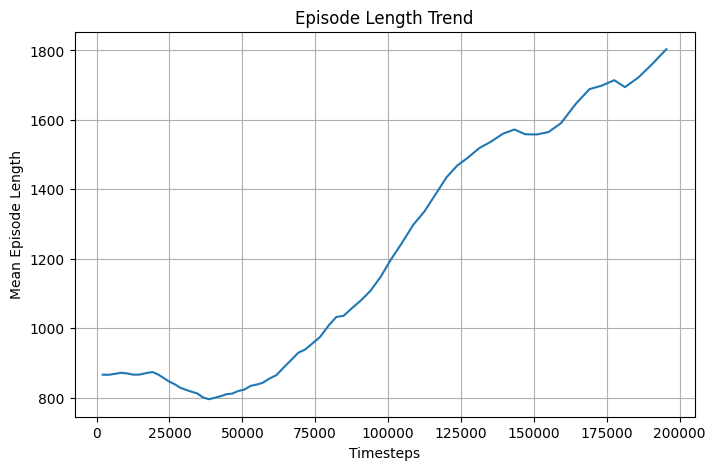

In [26]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import matplotlib.pyplot as plt

event_file = "/kaggle/working/logs/sharif_exp05_lr_1_5e4/DQN_1/events.out.tfevents.1784411338.ede3823e489d.161.0"

ea = EventAccumulator(event_file)
ea.Reload()

reward_events = ea.Scalars("rollout/ep_len_mean")

steps = [e.step for e in reward_events]
rewards = [e.value for e in reward_events]

plt.figure(figsize=(8,5))
plt.plot(steps, rewards)
plt.title("Episode Length Trend")
plt.xlabel("Timesteps")
plt.ylabel("Mean Episode Length")
plt.grid(True)
plt.show()

# Cross-Experiment Comparison

Aggregating reward and episode-length trends across every experiment with
available logs (exp04–exp10) to rank them and identify the best-performing
configuration overall.

**Conclusion:** `sharif_exp05_lr_1_5e4` (lr=1.5e-4) is the best experiment,
with final reward -17.45, best reward -16.66, and by far the longest
episode length (best 1803 steps) — consistent with the per-experiment
analysis above.

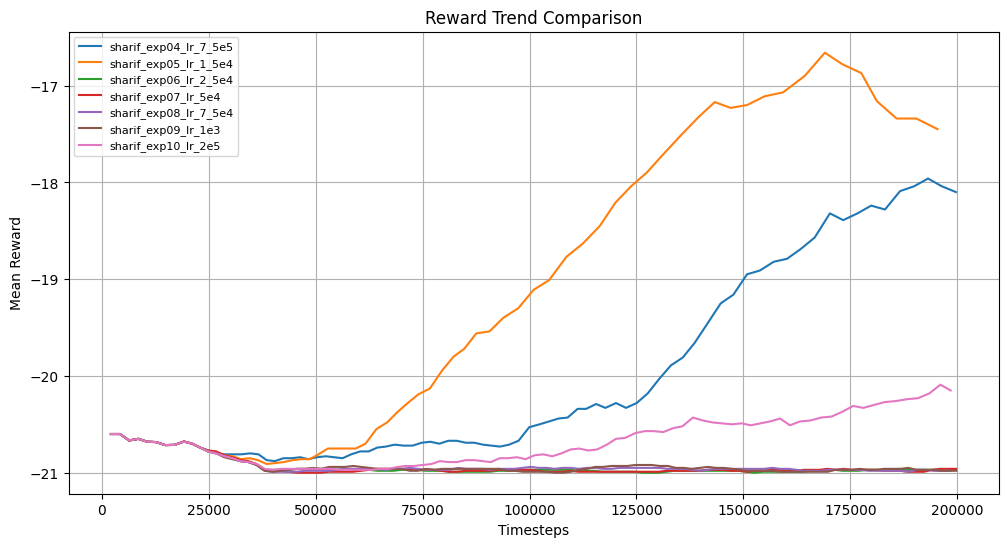

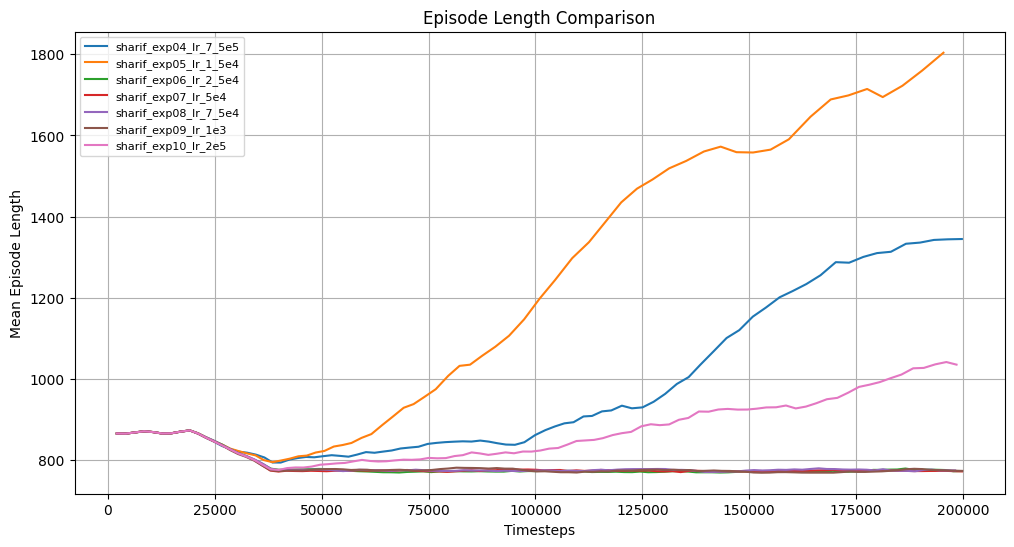

              Experiment  Final Reward  Best Reward  Final Episode Length  \
1  sharif_exp05_lr_1_5e4    -17.450001   -16.660000           1803.619995   
0  sharif_exp04_lr_7_5e5    -18.100000   -17.959999           1344.959961   
6    sharif_exp10_lr_2e5    -20.150000   -20.090000           1035.699951   
2  sharif_exp06_lr_2_5e4    -20.969999   -20.600000            773.710022   
3    sharif_exp07_lr_5e4    -20.959999   -20.600000            772.880005   
4  sharif_exp08_lr_7_5e4    -20.980000   -20.600000            775.299988   
5    sharif_exp09_lr_1e3    -20.980000   -20.600000            774.090027   

   Best Episode Length  
1          1803.619995  
0          1344.959961  
6          1042.099976  
2           873.777771  
3           873.777771  
4           873.777771  
5           873.777771  

BEST EXPERIMENT
Experiment              sharif_exp05_lr_1_5e4
Final Reward                       -17.450001
Best Reward                            -16.66
Final Episode Length        

In [25]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

LOG_DIR = "/kaggle/working/logs"

summary = []

plt.figure(figsize=(12,6))

for exp in sorted(os.listdir(LOG_DIR)):
    exp_path = os.path.join(LOG_DIR, exp)

    if not os.path.isdir(exp_path):
        continue

    event_file = None

    for root, dirs, files in os.walk(exp_path):
        for f in files:
            if f.startswith("events.out.tfevents"):
                event_file = os.path.join(root, f)
                break

    if event_file is None:
        continue

    ea = EventAccumulator(event_file)
    ea.Reload()

    tags = ea.Tags()["scalars"]

    if "rollout/ep_rew_mean" not in tags:
        continue

    rewards = ea.Scalars("rollout/ep_rew_mean")
    ep_lengths = ea.Scalars("rollout/ep_len_mean")

    reward_steps = [x.step for x in rewards]
    reward_values = [x.value for x in rewards]

    plt.plot(reward_steps, reward_values, label=exp)

    summary.append({
        "Experiment": exp,
        "Final Reward": reward_values[-1],
        "Best Reward": max(reward_values),
        "Final Episode Length": ep_lengths[-1].value,
        "Best Episode Length": max([x.value for x in ep_lengths]),
    })

plt.title("Reward Trend Comparison")
plt.xlabel("Timesteps")
plt.ylabel("Mean Reward")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()

# Episode Length Comparison

plt.figure(figsize=(12,6))

for exp in sorted(os.listdir(LOG_DIR)):
    exp_path = os.path.join(LOG_DIR, exp)

    if not os.path.isdir(exp_path):
        continue

    event_file = None

    for root, dirs, files in os.walk(exp_path):
        for f in files:
            if f.startswith("events.out.tfevents"):
                event_file = os.path.join(root, f)
                break

    if event_file is None:
        continue

    ea = EventAccumulator(event_file)
    ea.Reload()

    tags = ea.Tags()["scalars"]

    if "rollout/ep_len_mean" not in tags:
        continue

    ep_lengths = ea.Scalars("rollout/ep_len_mean")

    steps = [x.step for x in ep_lengths]
    values = [x.value for x in ep_lengths]

    plt.plot(steps, values, label=exp)

plt.title("Episode Length Comparison")
plt.xlabel("Timesteps")
plt.ylabel("Mean Episode Length")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()

# Summary Table
df = pd.DataFrame(summary)

df = df.sort_values("Best Reward", ascending=False)

print(df)

# Best Experiment

best = df.iloc[0]

print("\n==============================")
print("BEST EXPERIMENT")
print("==============================")
print(best)